# Accuracy Evaluator Tool



This Notebook discusses usage of Accuracy Evaluator Tool. The user can configure various plugins for pre processing, post processing, and metric evaluation. 

Please see below the high level workflow for executing your model on AIC100. Accuracy Evaluator is highlighted in red. 
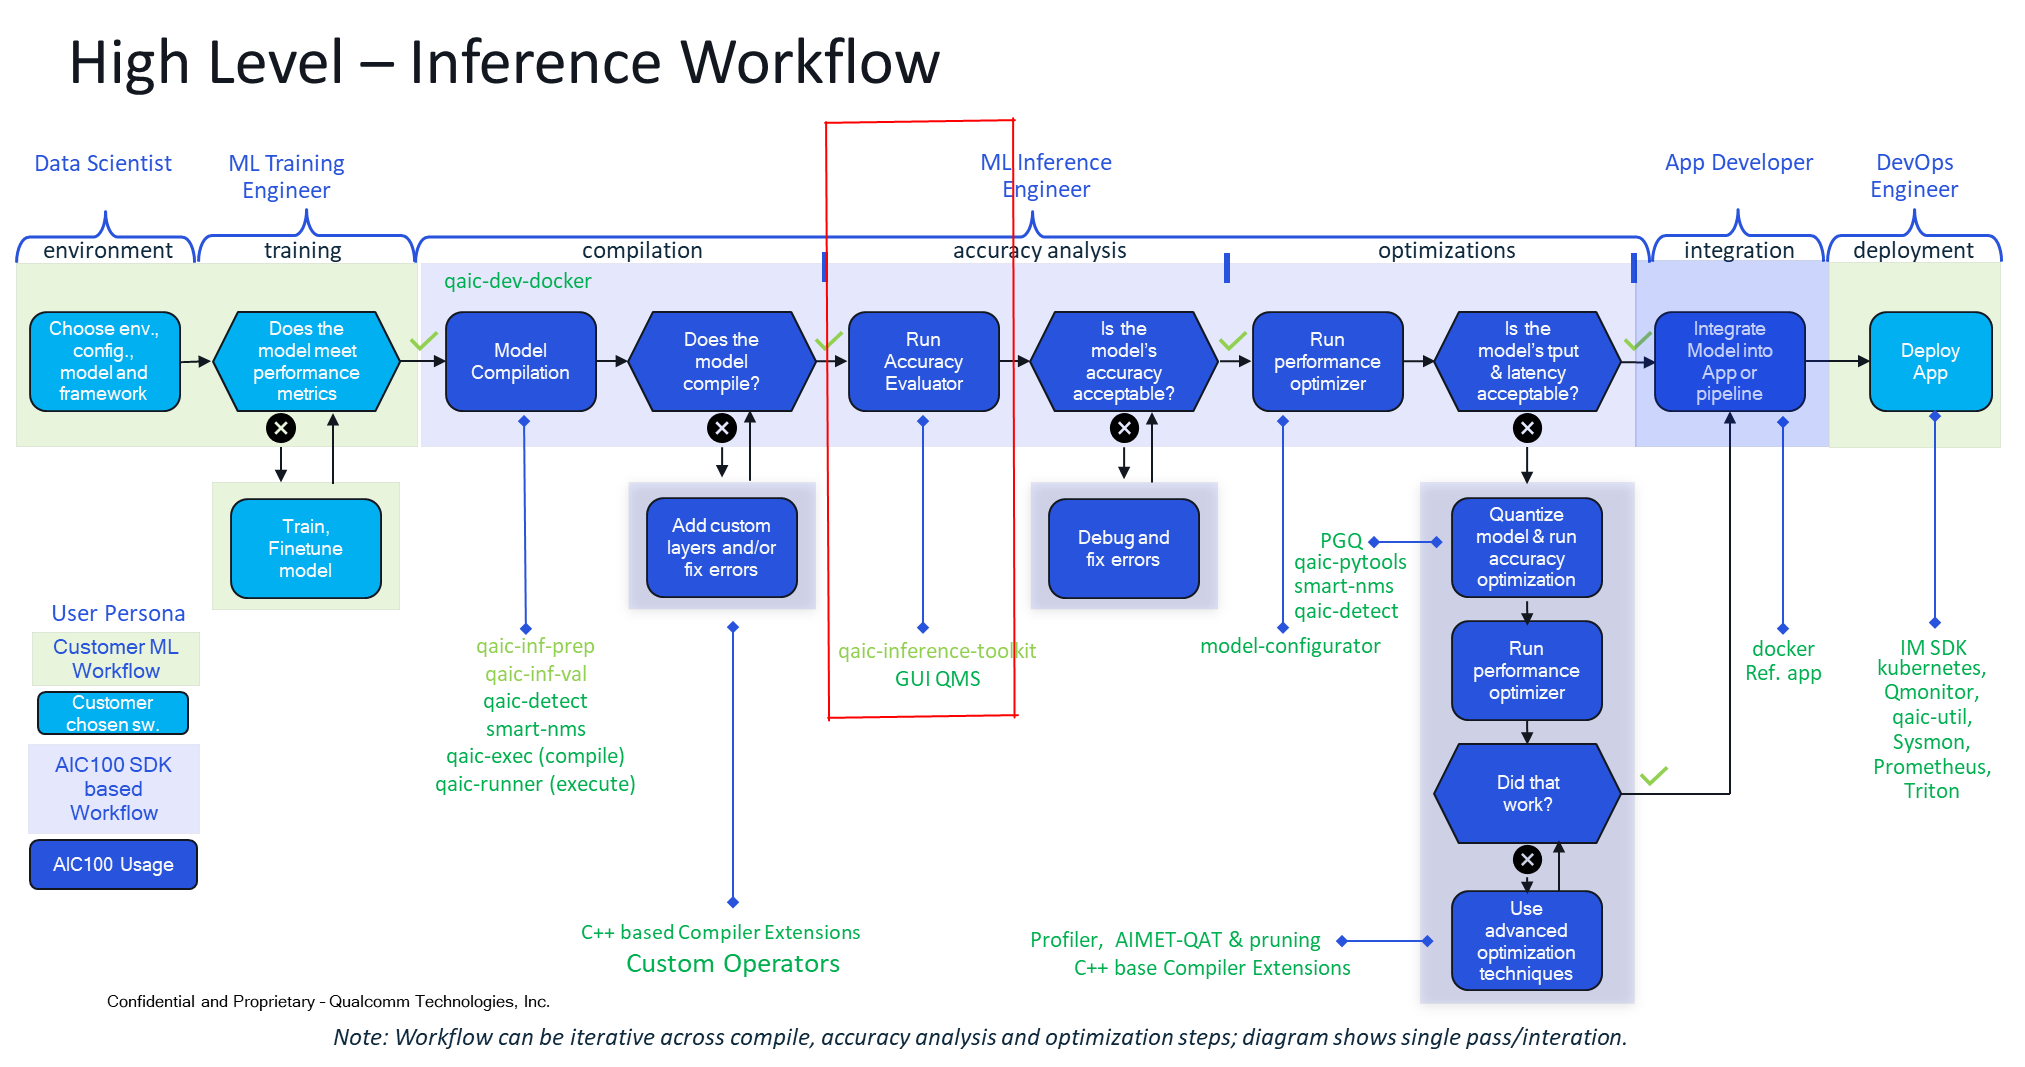

In [13]:
!/opt/qti-aic/dev/python/qaic-env/bin/python -m pip install ipykernel 
!source /opt/qti-aic/dev/python/qaic-env/bin/activate

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
Badly placed ()'s.


In [3]:
import sys
assert sys.executable  == '/opt/qti-aic/dev/python/qaic-env/bin/python'
!/opt/qti-aic/tools/qaic-version-util
!{sys.executable} --version

platform:AIC.1.9.1.25
apps:AIC.1.9.1.25
factory:not found
Python 3.8.16


## 1.  Starting and Ending at Different Pipeline Stages:

**Valid Pipeline Stages** : "preproc", "compiled", "infer", "postproc", "metric"


1.1. **Perform Preprocessing only**

User can use evaluator tool to only perform preprocessing of the dataset. This can be used for saving the preprocessing overhead for each evaluation while using the dataset.


In [4]:
model_config_path = "bert_base.yaml"

In [12]:
!{sys.executable} /opt/qti-aic/tools/qaic-pytools/qaic-acc-evaluator.py -silent \
        -config 'bert_base.yaml' -device-id 1 -pipeline-end preproc \
        -onnx-symbol sequence_length:128 \
        -work-dir preproc_only 

/opt/qti-aic/dev/python/qaic-env/lib/python3.8/site-packages/paramiko/transport.py:236: CryptographyDeprecationWarning: Blowfish has been deprecated
  "class": algorithms.Blowfish,
/opt/qti-aic/dev/python/qaic-env/lib/python3.8/site-packages/_distutils_hack/__init__.py:33: UserWarning: Setuptools is replacing distutils.
  warnings.warn("Setuptools is replacing distutils.")
INFO: Loading model config
INFO: Running Accuracy Evaluator using Memory Pipeline
INFO: Executing dataset plugins
100%|███████████████████████████████████████████| 48/48 [00:02<00:00, 21.19it/s]
convert squad examples to features: 100%|█| 10570/10570 [00:08<00:00, 1240.30it/
add example index and unique id: 100%|█| 10570/10570 [00:00<00:00, 115290.46it/s
add example index and unique id: 100%|████| 100/100 [00:00<00:00, 341277.79it/s]
INFO: Executing Preprocessors for calibration inputs
INFO: Calibration Preprocessing Took 0.05629277229309082 seconds.
INFO: Executing Preprocessors
INFO: Input Preprocessing Took 11.320

1.2 **Reuse Preprocessed Data and Start from Inference Stage**

User can use evaluator tool to use existing preprocessed dataset for evaluating models. This method avoids creating a new entry in datasets.yaml with the preprocessed datasaet details.

In [ ]:
!{sys.executable} /opt/qti-aic/tools/qaic-pytools/qaic-acc-evaluator.py -silent \
        -config {model_config_path} -device-id 0,1,2,3 -pipeline-start infer \
        -preproc-file preproc_only/preproc/processed-outputs.txt \
        -onnx-symbol sequence_length:128 \
        -debug \
        -calib-file preproc_only/calibration/processed-outputs.txt 

1.3. **Using Accuracy Evaluator till Compilation**:

Model compilation happens on Host(x86) machine, user has the flexiblity to compile the model on machine which doesnt have AIC100 card and then transfer the work directory (compiled binaries, processed inputs) to a machine having AIC100 card to perform evaluation.

In [7]:
!{sys.executable} /opt/qti-aic/tools/qaic-pytools/qaic-acc-evaluator.py -silent \
        -config {model_config_path} -device-id 1 -pipeline-end compiled \
        -platform-tag aic_fp16 -work-dir experiment_1

/opt/qti-aic/dev/python/qaic-env/lib/python3.8/site-packages/paramiko/transport.py:236: CryptographyDeprecationWarning: Blowfish has been deprecated
  "class": algorithms.Blowfish,
/opt/qti-aic/dev/python/qaic-env/lib/python3.8/site-packages/_distutils_hack/__init__.py:33: UserWarning: Setuptools is replacing distutils.
  warnings.warn("Setuptools is replacing distutils.")
INFO: Loading model config
INFO: Running Accuracy Evaluator using Memory Pipeline
INFO: Executing dataset plugins
100%|███████████████████████████████████████████| 48/48 [00:02<00:00, 22.48it/s]
convert squad examples to features: 100%|█| 10570/10570 [00:08<00:00, 1266.21it/
add example index and unique id: 100%|█| 10570/10570 [00:00<00:00, 117740.24it/s
add example index and unique id: 100%|████| 100/100 [00:00<00:00, 654337.60it/s]
INFO: [1]
INFO: Total platform configurations: 1
INFO: Total inputs for execution: 18498 and calibration: 0
INFO: Approximate disk usage  - 72.26 MB
INFO: Cleaning up model..
INFO: Defau

## 2. Execute Specific Platform based on tag

In [10]:
!{sys.executable} /opt/qti-aic/tools/qaic-pytools/qaic-acc-evaluator.py -silent \
        -config {model_config_path} -device-id 1  \
        -platform-tag=aic_fp16 -silent

/opt/qti-aic/dev/python/qaic-env/lib/python3.8/site-packages/paramiko/transport.py:236: CryptographyDeprecationWarning: Blowfish has been deprecated
  "class": algorithms.Blowfish,
/opt/qti-aic/dev/python/qaic-env/lib/python3.8/site-packages/_distutils_hack/__init__.py:33: UserWarning: Setuptools is replacing distutils.
  warnings.warn("Setuptools is replacing distutils.")
INFO: Loading model config
INFO: Running Accuracy Evaluator using Memory Pipeline
INFO: Executing dataset plugins
100%|███████████████████████████████████████████| 48/48 [00:02<00:00, 22.42it/s]
convert squad examples to features: 100%|█| 10570/10570 [00:08<00:00, 1261.04it/
add example index and unique id: 100%|█| 10570/10570 [00:00<00:00, 133875.05it/s
add example index and unique id: 100%|████| 100/100 [00:00<00:00, 496367.34it/s]
INFO: [1]
INFO: Total platform configurations: 1
INFO: Total inputs for execution: 18498 and calibration: 0
INFO: Approximate disk usage  - 72.26 MB
INFO: Cleaning up model..
INFO: Defau

## 3. Update Platform parameters based on tag dynamically while invoking

In [12]:
!{sys.executable} /opt/qti-aic/tools/qaic-pytools/qaic-acc-evaluator.py -silent \
        -config {model_config_path}  -device-id 1 \
        -platform-tag=aic_fp16 -platform-tag-params "aic_fp16,aic-num-cores:4" # "-platform-tag-params tag,param1:value1;param2:value2"

/opt/qti-aic/dev/python/qaic-env/lib/python3.8/site-packages/paramiko/transport.py:236: CryptographyDeprecationWarning: Blowfish has been deprecated
  "class": algorithms.Blowfish,
/opt/qti-aic/dev/python/qaic-env/lib/python3.8/site-packages/_distutils_hack/__init__.py:33: UserWarning: Setuptools is replacing distutils.
  warnings.warn("Setuptools is replacing distutils.")
INFO: Loading model config
INFO: Running Accuracy Evaluator using Memory Pipeline
INFO: Executing dataset plugins
100%|███████████████████████████████████████████| 48/48 [00:02<00:00, 22.54it/s]
convert squad examples to features: 100%|█| 10570/10570 [00:08<00:00, 1269.75it/
add example index and unique id: 100%|█| 10570/10570 [00:00<00:00, 143642.41it/s
add example index and unique id: 100%|████| 100/100 [00:00<00:00, 611414.58it/s]
INFO: [1]
INFO: Total platform configurations: 1
INFO: Total inputs for execution: 18498 and calibration: 0
INFO: Approximate disk usage  - 72.26 MB
INFO: Cleaning up model..
INFO: Defau

## 4. Measuring Performance Scores (Throughput and Latency)


In [16]:
!{sys.executable} /opt/qti-aic/tools/qaic-pytools/qaic-acc-evaluator.py -silent \
        -config {model_config_path}  -device-id 1 -platform-tag=aic_fp16 \
        -enable-perf -perf-iter-count 100

/opt/qti-aic/dev/python/qaic-env/lib/python3.8/site-packages/paramiko/transport.py:236: CryptographyDeprecationWarning: Blowfish has been deprecated
  "class": algorithms.Blowfish,
/opt/qti-aic/dev/python/qaic-env/lib/python3.8/site-packages/_distutils_hack/__init__.py:33: UserWarning: Setuptools is replacing distutils.
  warnings.warn("Setuptools is replacing distutils.")
INFO: Loading model config
INFO: Running Accuracy Evaluator using Memory Pipeline
INFO: Executing dataset plugins
100%|███████████████████████████████████████████| 48/48 [00:02<00:00, 22.20it/s]
convert squad examples to features: 100%|█| 10570/10570 [00:08<00:00, 1237.00it/
add example index and unique id: 100%|█| 10570/10570 [00:00<00:00, 114573.30it/s
add example index and unique id: 100%|████| 100/100 [00:00<00:00, 513378.70it/s]
INFO: [1]
INFO: Total platform configurations: 1
INFO: Total inputs for execution: 18498 and calibration: 0
INFO: Approximate disk usage  - 72.26 MB
INFO: Cleaning up model..
INFO: Defau

## 5. Using Comparators 

Comparator is useful feature when multiple configurations are provided and the user wants to find the inputs for which the maximum gap is observed with respect to the reference platform. Comparator is enabled by default and the tool supports various set of in built comparators.By default, average comparator is used.

The comparator option takes the fields below and lists the preprocessed inputs that caused top mismatches in model outputs (regarding the reference) amongst the complete input list.

- **type**: One of inbuilt comparator types (avg | abs| l1norm | l2norm | rme) or custom comparator. See below for using Custom Comparators.
- **tol**: Tolerance value - depends on per comparator described below:
    - *'abs'* - absolute % difference. Example: 0.01 means that a 1% difference in the absolute tensor values from the reference is marked as a mismatch.
    - For all other inbuilt comparators - this defines the number of decimal places to round to before evaluating the comparator.
- **fetch_top**: Out of all mismatched files, order by maximum % mismatch and write the fetch_top number of preprocessed input file paths in a file (<plat_name>_mm.txt) per platform. Default value: 1
- **enabled**: By default, enabled (True)

#### Example 

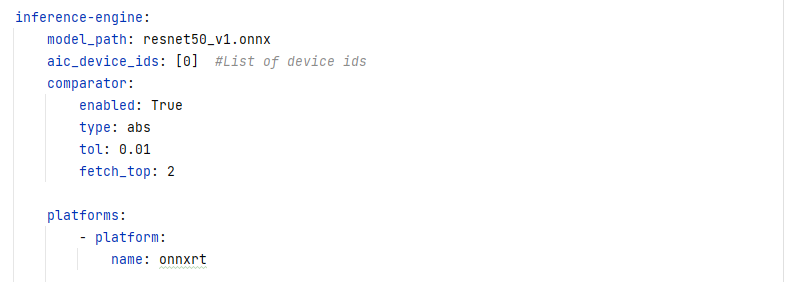


### 5.1 Using Built in Comparators

##### List of comparators supported:

- *AvgComparator* : **'avg'**                     --> comparison using Average error
- *TolComparator* : **'abs'**                     --> comparison using given tolerance value
- *NormComparato* : **'l1norm'** or **'l2norm'**  --> comparison using using L1_norm/L2_norm
- *RMEComparator* : **'rme'**                     --> comparison using root mean square error
- *KLDComparator* : **'kld'**                     --> comparison using KL Divergence
- *StdComparator* : **'std'**                     --> comparison using % difference in standard deviation
- *CosComparator* : **'cos'**                     --> comparison using Cosine Similarity 


### 5.2 Using Custom Comparators

Users can configure one or more custom defined comparators. Custom comparators are defined in a Python class extending the qaic_pytools.common.Comparators class and implementing a single compare method.
- **The custom comparator Python files are copied inside the directory configured in defaults.yaml configuration field common.custom_comparators_path.**
- There could be more than one comparator class defined in same Python file.
- Once created, the string returned by name() can be used as the comparator name like any other inbuilt comparators.

#### Comparator Class Interface:
```
class Comparators(ABC):
    """
    Comparators is an abstract class that compares two values using specific comparator type
    """

    def compare(self, op1, op2):
        """
        This method compares two numpy arrays with specific comparator type.
        Args:
            op1 : numpy array 1
            op2 : numpy array 2 
        Returns:
            match_percent : percentage of match between op1 and op2
        """
        pass

    def name(self):
        """
        Return a unique name of the comparator (without spaces)
        """
        return ''

    def display_name(self):
        """
        Returns the name to be displated on the comparison table.
        """
        return ''
```



#### Example 

In [19]:
import os 
import qaic_pytools.common.defaults as df
defaults = df.Defaults.getInstance()
custom_path = defaults.get_value("common.custom_comparators_path")
os.makedirs(custom_path,exist_ok=True)

In [20]:
%%writefile /opt/qti-aic/tools/qaic-pytools/custom_comparators/mycomp.py

from qaic_pytools.common.comparators import Comparators

class XYZ_cmp(Comparators):
    def __init__(self, tol=1e-5):
        # tol holds the tolerance threshold value passed by user.
        # to be used accordingly by the comparison logic.
        self._tol = tol
  
    def display_name(self): 
        # A string used to show the Column name in the final report. 
        return 'xyz(%)' 
    def compare(self, op1, op2): 
        # write compare logic 
        # op1 and op2 are two flattened numpy tensor outputs for the layer 
        # return percent match (0 -> 100) 
        # match_info string to give details on the mismatch or for edge cases. 
        return 100.0, match_info 


Overwriting /opt/qti-aic/tools/qaic-pytools/custom_comparators/mycomp.py
